# <span style="color:blue"> Lecture 9b - Word Clouds </span>

<font size = "5">

In  this lecture we will work with text data

- Basic summary and data manipulation
- Generate word clouds!

# <span style="color:blue"> I. Import Libraries and Data </span>

<font size = "5">

Start by installing "wordcloud" using <br>
conda install in your terminal

<font size = "5">

Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Install the package once in the notebook if it is missing:
!pip install wordcloud
from wordcloud import WordCloud, STOPWORDS

<font size = "5">

Import Data

- Congressional bills in the United States

In [3]:
bills_actions = pd.read_csv("data_raw/bills_actions.csv")
bills_actions.dtypes

Congress        int64
bill_number     int64
bill_type      object
action         object
main_action    object
category       object
member_id       int64
dtype: object

# <span style="color:blue"> II. Word Clouds from Single Strings  </span>

<font size = "5">

Word Cloud from sentence

(-0.5, 399.5, 199.5, -0.5)

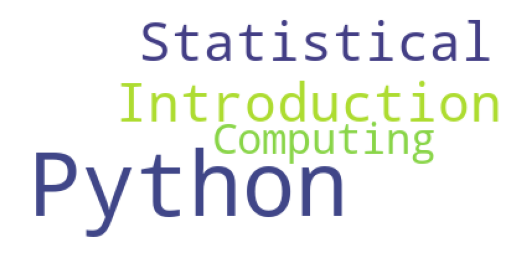

In [5]:
# We start by generating a string with text
# The WordCloud() command generates and object. To display it use "plt.imgshow()"
# Words with higher frequency will tend to appear larger (see advanced options)
# at the end for how to adjust the relative scaling

text = "Introduction to Statistical Computing Python Python Python Python Python"
word_cloud = WordCloud(background_color = "white").generate(text)
plt.imshow(word_cloud)
plt.axis("off")

<font size = "5">

Get word frequencies

In [ ]:
word_frequencies = WordCloud().process_text(text) 
# counts how many times word shows up in string
word_frequencies 

{'Introduction': 1, 'Statistical': 1, 'Computing': 1, 'Python': 5}

<font size = "5">

Adding stop words

- WordCloud drops common words like "to, from, the, a, ..."
- They're stored in STOPWORDS. We can add more!

(-0.5, 399.5, 199.5, -0.5)

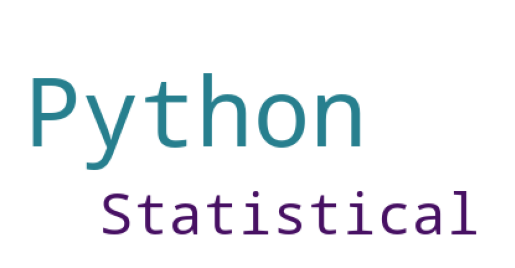

In [9]:
# Create adjusted list of stop words

stop_words = list(STOPWORDS) + ["Introduction","Computing"]
text = "Introduction to Statistical Computing Python Python Python Python Python"

# Plot results
# If you don't wan't any stopwords, use "stopwords = []" instead
word_cloud = WordCloud(background_color = "white",
                       stopwords = stop_words).generate(text)
plt.imshow(word_cloud)
plt.axis("off")

<font size = "5">

Try it yourself!

- Search in Wikipedia for an article.
- Copy a paragraph into Python and store it as <br>
a string variable called "text".
- Display a word cloud!

(-0.5, 399.5, 199.5, -0.5)

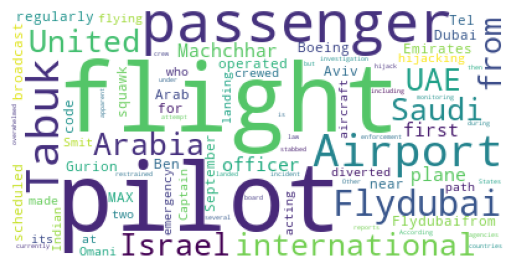

In [ ]:
# Write your own code

wiki_par = "Flydubai Flight 1073 was a regularly scheduled international passenger flight operated by Flydubai" +\
    "from Dubai International Airport in the United Arab Emirates (UAE) to Ben Gurion Airport near Tel Aviv, Israel." +\
         "On 30 September 2026, the Boeing 737 MAX 8 broadcast the squawk code for hijacking, diverted from its flight path," +\
            "and made an emergency landing at Tabuk Airport in Tabuk, Saudi Arabia." +\
                "The aircraft was crewed by two pilots: Indian Captain Smit Machchhar, who was the pilot flying," +\
                    "and an Omani first officer acting as pilot monitoring." +\
                        "According to passenger reports, the first officer stabbed Machchhar during the flight in an " +\
                            "apparent attempt to hijack the plane, but was overwhelmed and restrained by passengers and crew. " +\
                                "Other Flydubai pilots on board then landed the plane in Tabuk. The incident is currently under " +\
                                    "investigation by law enforcement agencies from several countries, including Israel, the UAE, Saudi Arabia, and the United States."

word_cloud = WordCloud(background_color = "white",
                       stopwords = ["the", "and", "to", "by", "was", 
                                    "in", "on", "a", "an", "as"]
                       ).generate(wiki_par)
plt.imshow(word_cloud)
plt.axis("off")


# <span style="color:blue"> III. Word Clouds + Pandas </span>

<font size = "5">

Concatanate column into single long sentence

In [17]:
# We start of with an empty string and sequentiall
# concatenate all the elements of bills["main_action"] together

list_categories = ["house bill","senate bill"]
bills = bills_actions.query('category in @list_categories')

text_bills = "".join(bills["action"])

<font size = "5">

Create WordCloud

(-0.5, 399.5, 199.5, -0.5)

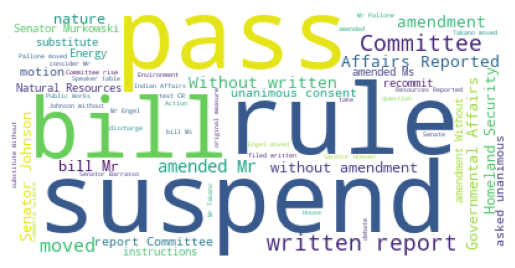

In [ ]:
word_cloud = WordCloud(background_color = "white").generate(text_bills)
                       
plt.imshow(word_cloud)
plt.axis("off")

<font size = "5">

Text by subgroup

In [ ]:
# Create sets of words by category
subset_bills_house  = bills_actions.query('category == "house bill"')
subset_bills_senate = bills_actions.query('category == "senate bill"')

# Create strings with all the words mentioned for those observations
text_house  = "".join(subset_bills_house["action"])
text_senate = "".join(subset_bills_senate["action"])

# to see what it does
print(text_house)

ASSUMING FIRST SPONSORSHIP - Mr. Trone asked unanimous consent that he may hereafter be considered as the first sponsor of H.R. 1075 , a bill originally introduced by Representative Elijah Cummings, for the purpose of adding cosponsors and requesting reprintings pursuant to clause 7 of rule XII. Agreed to without objection. Action By: House of RepresentativesMotion to place bill on Consensus Calendar filed by Mr. Peterson. Action By: House of RepresentativesASSUMING FIRST SPONSORSHIP - Mrs. Trahan asked unanimous consent that she may hereafter be considered as the first sponsor of H.R. 1915 , a bill originally introduced by Representative Cummings, for the purpose of adding cosponsors and requesting reprintings pursuant to clause 7 of rule XII. Agreed to without objection. Action By: House of RepresentativesASSUMING FIRST SPONSORSHIP - Mr. Mfume asked unanimous consent that he may hereafter be considered as the first sponsor of H.R. 2981 , a bill originally introduced by Representative

<font size = "5" >
Plotting multiple wordclouds

Text(0.5, 1.0, 'Senate')

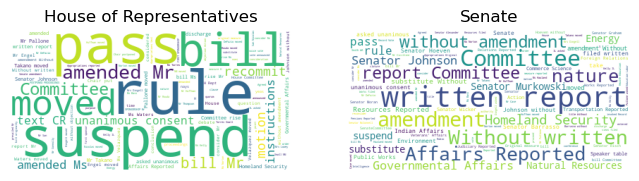

In [22]:
# Use subplots to create figures with multiple plots
fig, list_subfig = plt.subplots(1,2,figsize = [8,3])

# wordclouds of the joined strings/observations
word_cloud_house = WordCloud(background_color = "white").generate(text_house)                       
list_subfig[0].imshow(word_cloud_house)
list_subfig[0].axis("off")
list_subfig[0].set_title("House of Representatives")

word_cloud_senate = WordCloud(background_color = "white").generate(text_senate)                       
list_subfig[1].imshow(word_cloud_senate)
list_subfig[1].axis("off")
list_subfig[1].set_title("Senate")

<font size = "5">

**Note:** In general, many possibilities for splitting by subgroups! <br>
Years, geography, type of speaker, type of document, etc.

<font size = "5">
Try it yourself!

- Obtain the text for the categories "house resolution" <br>
and "senate resolution" (separately)
- Plot word clouds for the column "action" for each of the <br>
two categories using ``` plt.subplots()``` and the code <br>
shown above


In [11]:
# Write your own code





# <span style="color:blue"> V. (Optional) Advanced Settings </span>

(-0.5, 399.5, 199.5, -0.5)

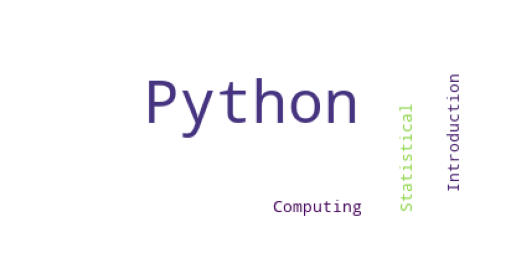

In [15]:
# Relative scaling of high-frequency words

text = "Introduction to Statistical Computing Python Python Python Python Python"
word_cloud = WordCloud(width = 400,
                       height = 200,
                       relative_scaling = 0.9, # or "auto"
                       background_color = "white").generate(text)
plt.imshow(word_cloud)
plt.axis("off")